<a href="https://colab.research.google.com/github/binhminh276/hcmc-house-price_prediction/blob/main/notebooks/10_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phân tích giá nhà theo khu vực

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("processed_dataset_cleand_new.csv", decimal=",", sep=";", encoding="utf-8")
df

,ID,Diện tích,Khoảng giá,Số phòng ngủ,"Số phòng tắm, vệ sinh",Pháp lý,Nội thất,Ngày hết hạn,Mặt tiền,Gần bệnh viện,Gần chợ,Gần trường học,Cao tầng,Quy hoạch,Phường,Quận,Giá m2
0,1,54.0,8.50,3,4,Không rõ,Không rõ,18/03/2026,0,0,0,0,1,0,Phường 5,Gò Vấp,0.157407
1,2,28.4,7.00,3,3,Sổ riêng,Nội thất cơ bản,18/03/2026,1,1,1,0,1,0,Phường 4,Quận 1,0.246479
2,3,69.0,3.30,3,3,Sổ riêng,Không rõ,16/03/2026,1,0,1,1,1,0,Phường Long Phước,Thủ Đức,0.047826
3,4,78.2,6.95,3,3,Sổ riêng,Không rõ,18/03/2026,1,0,0,0,1,0,Phường Trường Thọ,Thủ Đức,0.088875
4,5,75.9,6.70,2,2,Sổ riêng,Không rõ,18/03/2026,1,0,0,0,0,1,Phường Linh Tây,Thủ Đức,0.088274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11244,11324,71.0,6.90,3,3,Không rõ,Không rõ,13/03/2026,0,0,0,0,1,0,Phường 16,Gò Vấp,0.097183
11245,11325,81.1,7.15,4,6,Sổ riêng,Full nội thất,11/03/2026,0,0,1,1,0,0,Phường Thới An,Quận 1,0.088163
11246,11326,23.0,2.50,2,3,Sổ riêng,Không rõ,13/03/2026,0,1,1,0,1,1,Phường Linh Xuân,Thủ Đức,0.108696
11247,11327,100.0,18.50,4,3,Sổ riêng,Không rõ,16/03/2026,1,0,0,0,1,0,Phường 14,Phú Nhuận,0.185000


In [ ]:
df["Giá m2 (triệu)"] = df["Giá m2"] * 1000
df[["Giá m2", "Giá m2 (triệu)"]].head()

,Giá m2,Giá m2 (triệu)
0,0.157407,157.407
1,0.246479,246.479
2,0.047826,47.826
3,0.088875,88.875
4,0.088274,88.274


## Phân tích theo quận/huyện

### Phân tích So sánh sự chênh lệch giữa các khu vực

In [ ]:
# Tính mean (trung bình), median (trung vị), std (độ lệch chuẩn), count (số lượng tin đăng), max (cao nhất) và min (thấp nhất)
stats_by_district = df.groupby('Quận')['Giá m2 (triệu)'].agg(['mean', 'median', 'std', 'count', 'max', 'min']).sort_values(by='mean', ascending=False)

# Tính độ lệch % giữa Mean và Median
stats_by_district["Chêch lệch (%)"] = (stats_by_district["mean"] - stats_by_district["median"]) / stats_by_district["median"] * 100
print("Mức chêch lệch giữa Mean và Median theo từng quận:")
print(stats_by_district[["mean", "median", "Chêch lệch (%)", "max", "min"]])
print("-"*50)

# Xác định Top 3 quận cao nhất và Top 3 quận nhất
top_3 = stats_by_district.head(3)
bottom_3 = stats_by_district.tail(3)

# Tính tỷ lệ chênh lệch giữa Top 3 cao nhất và Top 3 thấp nhất
avg_top_3 = top_3['mean'].mean()
avg_bottom_3 = bottom_3['mean'].mean()
ratio = avg_top_3 / avg_bottom_3

print("Top 3 quận cao nhất:")
print(top_3[["mean", "median", "Chêch lệch (%)", "std", "max", "min"]])
print("-"*50)
print("\nTop 3 quận thấp nhất:")
print(bottom_3[["mean", "median", "Chêch lệch (%)", "std", "max", "min"]])
print("-"*50)
print(f"Giá trung bình Top 3 quận cao nhất: {avg_top_3:.4f} triệu/m2")
print(f"Giá trung bình Top 3 quận thấp nhất: {avg_bottom_3:.4f} triệu/m2")
print(f"=> Top 3 quận cao nhất đắt gấp khoảng {ratio:.2f} lần so với Top 3 thấp nhất.")

Mức chêch lệch giữa Mean và Median theo từng quận:
                  mean    median  Chêch lệch (%)       max     min
Quận                                                              
Quận 3      313.809029  267.4510       17.333280  1153.846  54.717
Quận 5      228.621857  187.0230       22.242642   771.912  35.938
Phú Nhuận   226.359877  201.8850       12.123177  1704.545  39.459
Quận 1      214.980610  129.0745       66.555447  2163.651  22.000
Tân Bình    169.207896  155.5560        8.776193   918.791  19.102
Bình Thạnh  166.540797  151.0870       10.228410   756.303  20.864
Gò Vấp      143.952031  134.7125        6.858703   457.627  23.529
Quận 4      142.459641  113.2140       25.832177   604.651  23.766
Quận 6      131.697426  132.1430       -0.337191   466.667  17.890
Quận 7      127.371530  102.1980       24.632117   629.723  22.222
Thủ Đức     123.326322   97.1660       26.923329  1106.636  24.203
Tân Phú     113.101598  106.0610        6.638253   350.318   6.085
Cần Giờ    

/tmp/ipykernel_2810/1752629458.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(plot_df["Quận"], rotation=75)


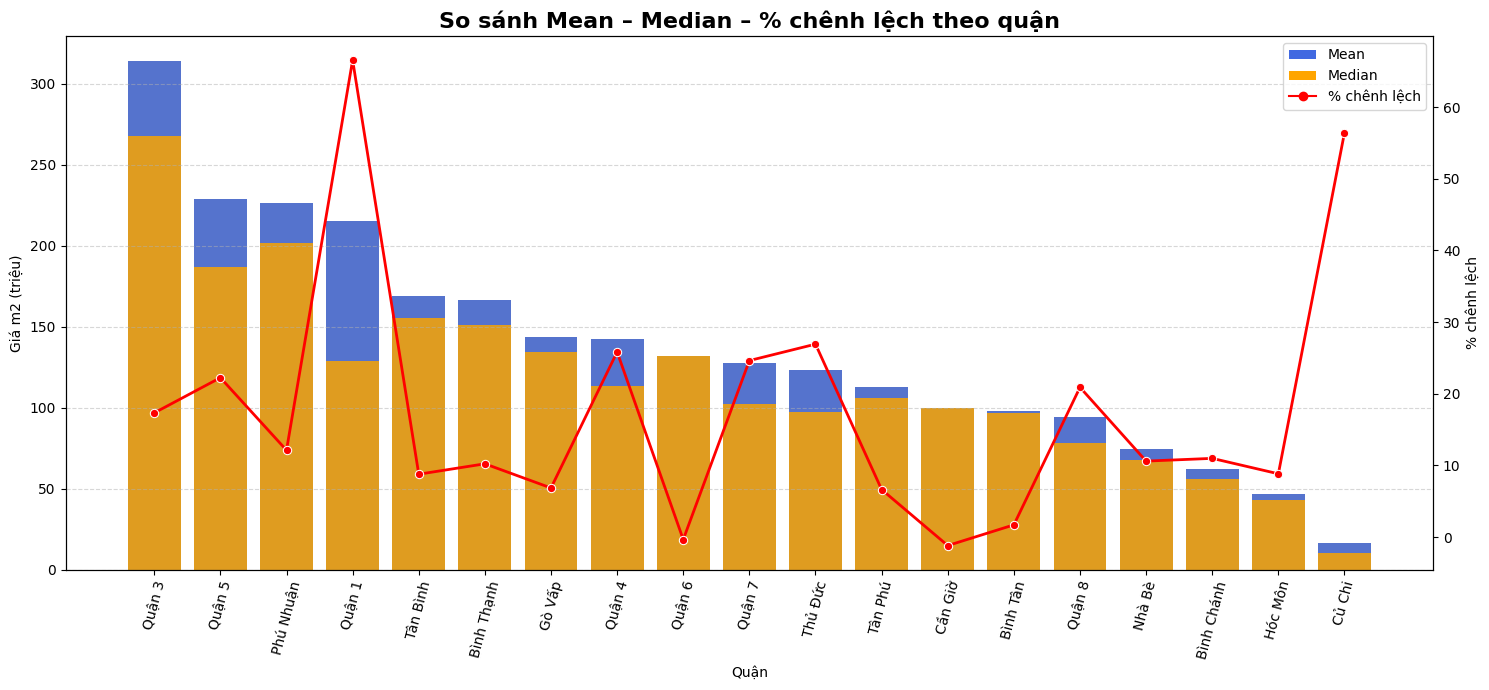

In [ ]:
# Vẽ biểu đồ So sánh mức độ chênh lệch giữa trung bình và trung vị giá theo khu vực
plot_df = stats_by_district.reset_index()
fig, ax1 = plt.subplots(figsize=(15,7))

sns.barplot(data=plot_df,x="Quận",y="mean",color="royalblue",ax=ax1)
sns.barplot(data=plot_df,x="Quận",y="median",color="orange",ax=ax1)

ax1.set_ylabel("Giá m2 (triệu)")
ax1.set_xticklabels(plot_df["Quận"], rotation=75)
ax1.set_title("So sánh Mean – Median – % chênh lệch theo quận",fontsize=16,fontweight="bold")

ax2 = ax1.twinx()
line = sns.lineplot(data=plot_df,x="Quận",y="Chêch lệch (%)",color="red",marker="o",linewidth=2,ax=ax2)
ax2.set_ylabel("% chênh lệch")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor="royalblue", label="Mean"),
    Patch(facecolor="orange", label="Median"),
    Line2D([0], [0], color="red", marker="o", label="% chênh lệch")
]
ax1.legend(handles=legend_elements,loc="upper right")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Biến động (Phòng ngừa rủi ro số liệu)
-  Chỉ số $CV = (Std / Mean)$ của từng quận là bao nhiêu?
    - Mục đích: Nếu CV > 1, giá trung bình của quận đó cực kỳ không ổn định và không nên dùng làm đại diện cho toàn quận.

- Tại mỗi quận, có bao nhiêu % số nhà có giá trị thấp hơn mức giá trung bình (Mean) của chính quận đó?

In [ ]:
# Hệ số biến thiên (CV - Coefficient of Variation)
group_stats = df.groupby("Quận")["Giá m2 (triệu)"].agg(mean="mean",std="std",count="count")
group_stats["CV"] = group_stats["std"] / group_stats["mean"]
print("Hệ số biến thiên (CV) theo từng quận:")
print(group_stats[['mean', 'std', 'CV']].sort_values(by='CV', ascending=False))

Hệ số biến thiên (CV) theo từng quận:
                  mean         std        CV
Quận                                        
Quận 1      214.980610  220.158407  1.024085
Củ Chi       16.285755   15.590413  0.957304
Thủ Đức     123.326322   90.558910  0.734303
Quận 5      228.621857  156.728852  0.685537
Quận 4      142.459641   91.791734  0.644335
Quận 7      127.371530   79.943074  0.627637
Phú Nhuận   226.359877  137.672091  0.608200
Quận 3      313.809029  185.643685  0.591582
Quận 8       94.302102   54.477477  0.577691
Cần Giờ      98.822458   56.384519  0.570564
Quận 6      131.697426   74.260675  0.563873
Bình Chánh   62.065064   34.899119  0.562299
Nhà Bè       74.636750   38.248710  0.512465
Tân Bình    169.207896   86.347491  0.510304
Bình Thạnh  166.540797   82.192916  0.493530
Tân Phú     113.101598   52.751100  0.466405
Hóc Môn      47.050714   20.836361  0.442849
Gò Vấp      143.952031   61.832960  0.429539
Bình Tân     98.150162   39.900855  0.406529


/tmp/ipykernel_2810/274996901.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(cv_df.index,rotation=75)


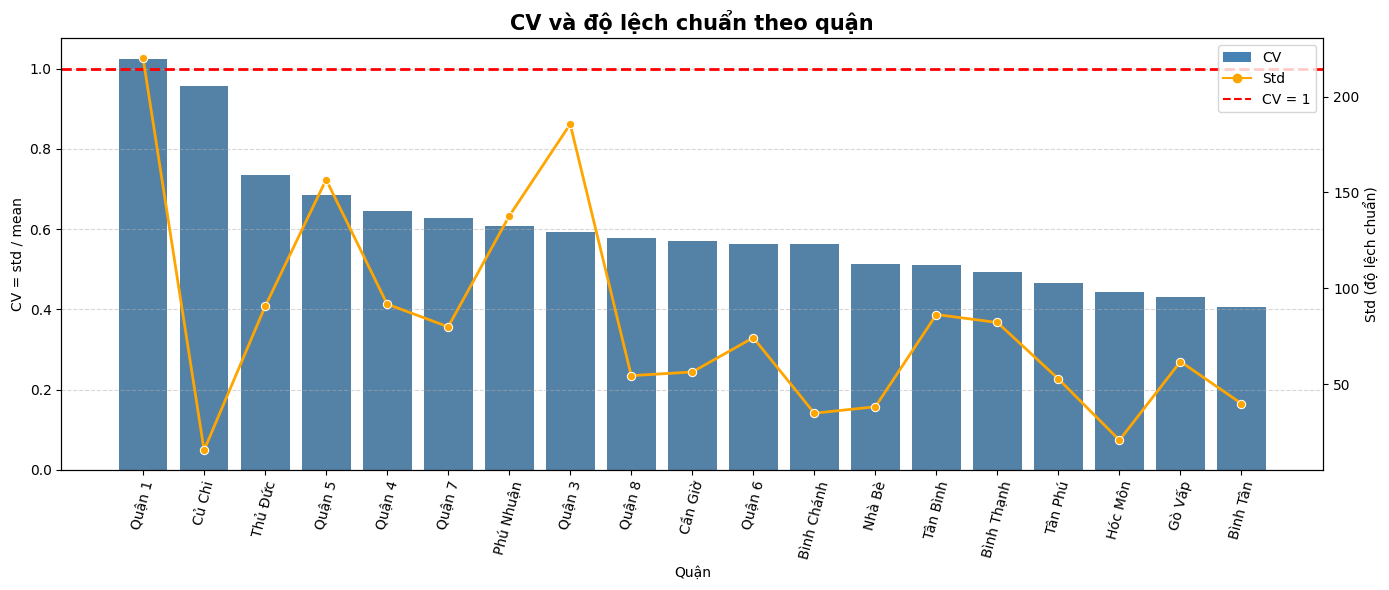

In [ ]:
# Vẽ biểu đồ
cv_df = group_stats.sort_values(by="CV", ascending=False)
fig, ax1 = plt.subplots(figsize=(14,6))
sns.barplot(x=cv_df.index,y=cv_df["CV"],color="steelblue",ax=ax1)
ax1.set_ylabel("CV = std / mean")
ax1.set_xlabel("Quận")
ax1.set_xticklabels(cv_df.index,rotation=75)
ax1.set_title("CV và độ lệch chuẩn theo quận",fontsize=15,fontweight="bold")

# đường CV = 1
ax1.axhline(1,color="red",linestyle="--",linewidth=2)
ax2 = ax1.twinx()
sns.lineplot(x=cv_df.index,y=cv_df["std"],color="orange",marker="o",linewidth=2,ax=ax2)
ax2.set_ylabel("Std (độ lệch chuẩn)")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor="steelblue", label="CV"),
    Line2D([0],[0], color="orange", marker="o", label="Std"),
    Line2D([0],[0], color="red", linestyle="--", label="CV = 1")]
ax1.legend(handles=legend_elements,loc="upper right")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2810/879727854.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Quận', y='Giá m2', order=order, palette="Set3")


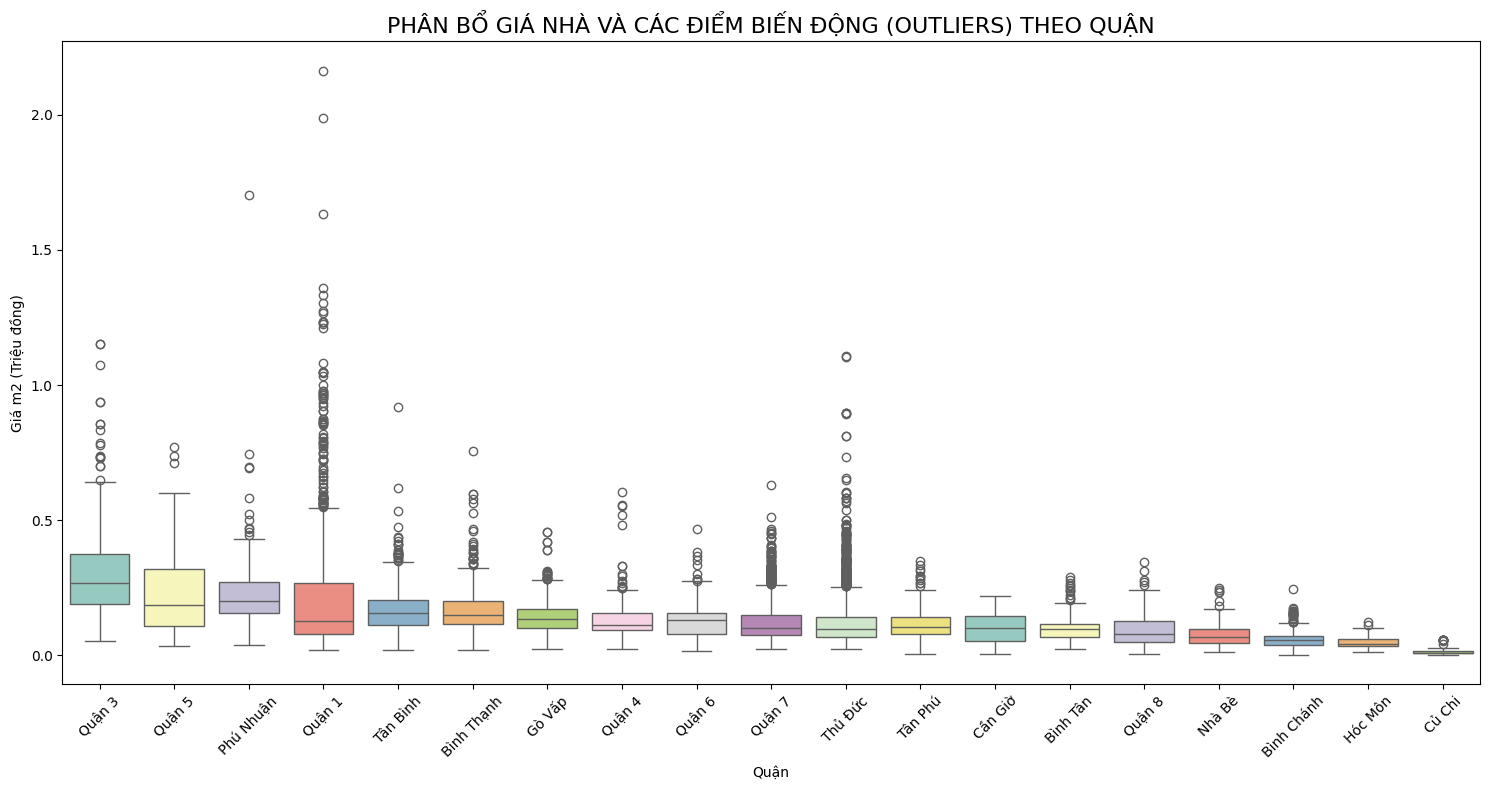

In [ ]:
stats_by_district = df.groupby('Quận')['Giá m2 (triệu)'].agg(['mean', 'median', 'std', 'count', 'min', 'max']).sort_values(by='mean', ascending=False)
stats_by_district["Chêch lệch (%)"] = (stats_by_district["mean"] - stats_by_district["median"]) / stats_by_district["median"] * 100
plt.figure(figsize=(15, 8))
order = stats_by_district.index # Sắp xếp các quận theo giá giảm dần
sns.boxplot(data=df, x='Quận', y='Giá m2', order=order, palette="Set3")
plt.title('PHÂN BỔ GIÁ NHÀ VÀ CÁC ĐIỂM BIẾN ĐỘNG (OUTLIERS) THEO QUẬN', fontsize=16)
plt.ylabel('Giá m2 (Triệu đồng)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Phân tích giá theo phường

### Quận 1

In [ ]:
# Lọc dữ liệu Quận 1
q1_df = df[df['Quận'] == 'Quận 1'].copy()
# Thống kê theo phường
q1_stats = ( q1_df
    .groupby('Phường')['Giá m2']
    .agg(mean='mean', median='median', std='std', count='count', max='max', min='min')
    .reset_index()
)

# Tính CV và % chênh lệch
q1_stats['CV'] = q1_stats['std'] / q1_stats['mean']
q1_stats['Diff_Pct'] = (q1_stats['mean'] - q1_stats['median']) / q1_stats['median'] * 100
q1_stats = q1_stats.round(2)


# XÁC ĐỊNH PHƯỜNG GÂY BIẾN ĐỘNG
# Phường có CV cao nhất (biến động mạnh nhất)
max_cv = q1_stats.loc[q1_stats['CV'].idxmax()]

# Phường có giá cao nhất
max_price = q1_stats.loc[q1_stats['mean'].idxmax()]

# Phường có giá thấp nhất
min_price = q1_stats.loc[q1_stats['mean'].idxmin()]

print("\n--- Phường biến động mạnh nhất ---")
print(max_cv)
print("\n--- Phường có giá cao nhất ---")
print(max_price)
print("\n--- Phường có giá thấp nhất ---")
print(min_price)
print("-"*100)

# PHÂN NHÓM THEO MỨC ĐỘ BIẾN ĐỘNG
high_volatility = q1_stats[q1_stats['CV'] > 1]          # cực kỳ biến động
medium_volatility = q1_stats[(q1_stats['CV'] > 0.6) & (q1_stats['CV'] <= 1)]
low_volatility = q1_stats[q1_stats['CV'] <= 0.6]

print("\n--- Phường có CV > 1 (Gây biến động chính) CÓ CV > 1 ---")
print(high_volatility[['Phường', 'mean', 'std', 'CV', 'Diff_Pct', 'max']])
print("\n--- Phường biến động trung bình ---")
print(medium_volatility[['Phường', 'mean', 'std', 'CV']])
print("\n--- Phường ổn định ---")
print(low_volatility[['Phường', 'mean', 'std', 'CV']])
print("-"*100)

# KIỂM TRA: BIẾN ĐỘNG DO TOÀN QUẬN HAY DO CỤC BỘ
# Tính CV toàn quận
q1_mean = q1_df['Giá m2'].mean()
q1_std = q1_df['Giá m2'].std()
q1_cv = q1_std / q1_mean
print("\nCV toàn Quận 1:", round(q1_cv, 3))

# Trung bình CV các phường
avg_ward_cv = q1_stats['CV'].mean()
print("CV trung bình các phường:", round(avg_ward_cv, 3))
print("-"*100)

# PHÁT HIỆN OUTLIER (NGUYÊN NHÂN CV > 1)
# Xác định các phường có max quá lớn so với median
q1_stats['Outlier_Ratio'] = q1_stats['max'] / q1_stats['median']
extreme_outliers = q1_stats[q1_stats['Outlier_Ratio'] > 5]
print("\n--- Phường có Ourlier cực lớn ---")
print(extreme_outliers[['Phường', 'median', 'max', 'Outlier_Ratio']])
print("-"*100)


if q1_cv > avg_ward_cv:
    print("→ Biến động Quận 1 KHÔNG đồng đều, chủ yếu do một số phường gây ra.")
else:
    print("→ Biến động phân bố tương đối đều giữa các phường.")
if len(high_volatility) > 0:
    print(f"→ Có {len(high_volatility)} phường có CV > 1, đây là nguyên nhân chính làm CV toàn quận cao.")
if len(extreme_outliers) > 0:
    print("→ Tồn tại outlier rất lớn (giá cực cao), làm tăng mạnh độ lệch chuẩn.")


--- Phường biến động mạnh nhất ---
Phường      Phường Cầu Ông Lãnh
mean                       0.43
median                     0.32
std                         0.4
count                        21
max                        1.99
min                        0.17
CV                         0.94
Diff_Pct                  33.61
Name: 21, dtype: object

--- Phường có giá cao nhất ---
Phường      Phường Bến Thành
mean                    0.61
median                  0.57
std                      0.3
count                     56
max                     1.36
min                      0.1
CV                      0.48
Diff_Pct                7.58
Name: 18, dtype: object

--- Phường có giá thấp nhất ---
Phường      Phường Trung Mỹ Tây
mean                       0.07
median                     0.07
std                        0.03
count                        31
max                        0.14
min                        0.04
CV                         0.37
Diff_Pct                   3.28
Name: 29, dtyp

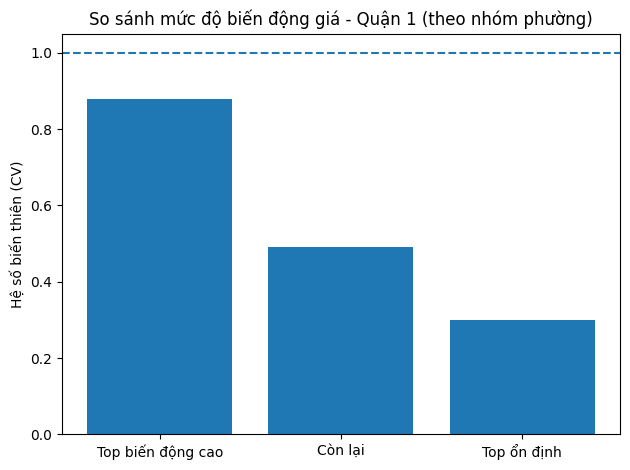

In [ ]:
# Vẽ biểu đồ mức độ biến động
q1_stats = q1_stats.sort_values(by='CV', ascending=False)
top3 = q1_stats.head(3)
bottom3 = q1_stats.tail(3)
others = q1_stats.iloc[3:-3]
group_labels = ['Top biến động cao', 'Còn lại', 'Top ổn định']
group_values = [
    top3['CV'].mean(),
    others['CV'].mean(),
    bottom3['CV'].mean()
]
plt.figure()
plt.bar(group_labels, group_values)
# Đường CV = 1
plt.axhline(y=1, linestyle='--')
plt.ylabel('Hệ số biến thiên (CV)')
plt.title('So sánh mức độ biến động giá - Quận 1 (theo nhóm phường)')
plt.tight_layout()
plt.show()

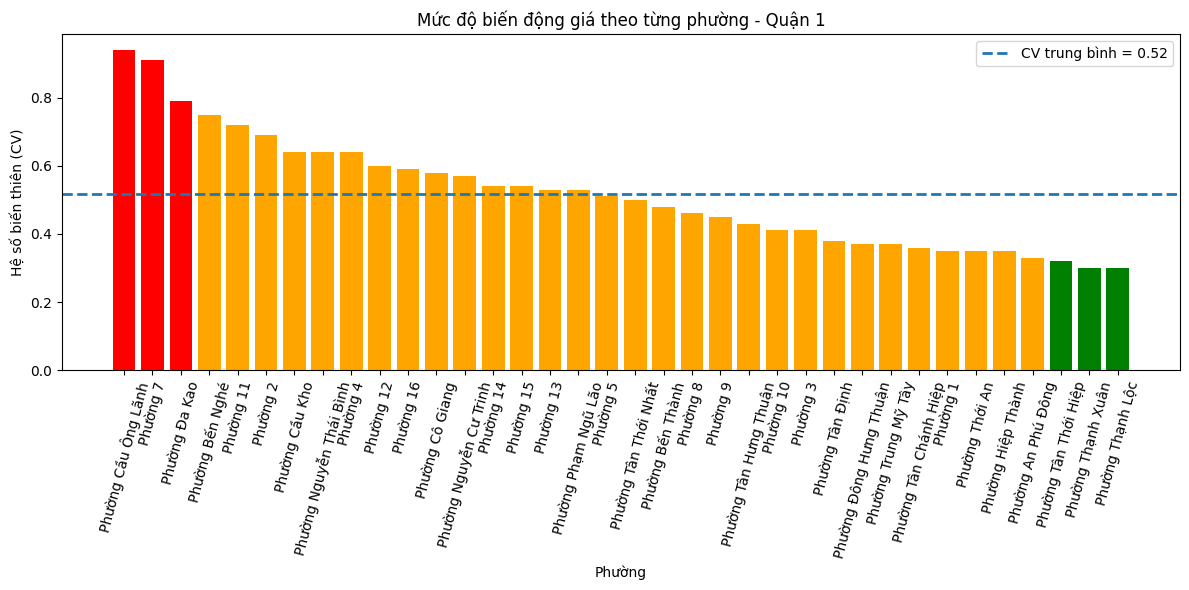

In [ ]:
# Vẽ biểu đồ thể hiện biến động (CV) giá theo từng phường của Quận 1
cv_df = q1_stats.sort_values(by="CV", ascending=False)
cv_df = cv_df.dropna(subset=['CV'])
top3 = cv_df.head(3)['Phường'].tolist()
bottom3 = cv_df.tail(3)['Phường'].tolist()
def get_color(ward):
    if ward in top3:
        return 'red'
    elif ward in bottom3:
        return 'green'
    else:
        return 'orange'

colors = [get_color(w) for w in cv_df['Phường']]
plt.figure(figsize=(12,6))
plt.bar(
    cv_df['Phường'],
    cv_df['CV'],
    color=colors
)
# CV trung bình
cv_mean = cv_df['CV'].mean()
plt.axhline(
    y=cv_mean,
    linestyle='--',
    linewidth=2,
    label=f'CV trung bình = {cv_mean:.2f}'
)
plt.xticks(rotation=75)
plt.ylabel("Hệ số biến thiên (CV)")
plt.xlabel("Phường")
plt.title("Mức độ biến động giá theo từng phường - Quận 1")
plt.legend()
plt.tight_layout()
plt.show()

### Củ chi

In [ ]:
cc_df = df[df['Quận'] == 'Củ Chi'].copy()
cc_stats = (
    cc_df
    .groupby('Phường')['Giá m2']
    .agg(mean='mean', median='median', std='std', count='count', max='max', min='min')
    .reset_index()
)
cc_stats['CV'] = cc_stats['std'] / cc_stats['mean']
cc_stats['Diff_Pct'] = (cc_stats['mean'] - cc_stats['median']) / cc_stats['median'] * 100
cc_stats = cc_stats.round(2)

# Xác định các xã đặc biệt
max_cv = cc_stats.loc[cc_stats['CV'].idxmax()]
min_price = cc_stats.loc[cc_stats['mean'].idxmin()]
max_price = cc_stats.loc[cc_stats['mean'].idxmax()]
print("\n--- Xã biến động mạnh nhất ---")
print(max_cv)
print("\n--- Xã có giá thấp nhất ---")
print(min_price)
print("\n--- Xã có giá cao nhất ---")
print(max_price)
print("-"*100)

# CV toàn huyện và từng xã
cc_mean = cc_df['Giá m2'].mean()
cc_std = cc_df['Giá m2'].std()
cc_cv = cc_std / cc_mean
avg_ward_cv = cc_stats['CV'].mean()
print("\nCV toàn Củ Chi:", round(cc_cv, 3))
print("CV trung bình các xã:", round(avg_ward_cv, 3))
print("-"*100)

# Kiểm tra Outlier
cc_stats['Outlier_Ratio'] = cc_stats['max'] / cc_stats['median']
extreme = cc_stats[cc_stats['Outlier_Ratio'] > 5]
print("\n--- Xã có Outlier cực lớn ---")
print(extreme[['Phường','median','max','Outlier_Ratio']])
print("-"*100)

if cc_cv > avg_ward_cv:
    print("→ Biến động giá tại Củ Chi không đồng đều, chỉ tập trung ở một số xã.")
else:
    print("→ Biến động phân bố tương đối đều giữa các xã.")
if len(extreme) > 0:
    print("→ Tồn tại outlier giá cao làm tăng độ lệch chuẩn.")
else:
    print("→ Không có outlier quá lớn, nhưng vẫn có chênh lệch giữa các xã.")
if cc_mean < df['Giá m2'].mean():
    print("→ Giá trung bình Củ Chi thấp hơn mặt bằng chung.")
if cc_cv > avg_ward_cv:
    print("→ CV cao dù giá thấp vì mean nhỏ, chỉ cần độ lệch nhỏ cũng làm CV tăng.")
    print("→ Có sự khác biệt giá giữa các xã, làm tăng độ phân tán toàn huyện.")


--- Xã biến động mạnh nhất ---
Phường      Xã Tân Thông Hội
mean                    0.01
median                  0.01
std                     0.01
count                     13
max                     0.03
min                      0.0
CV                      0.66
Diff_Pct               20.53
Name: 15, dtype: object

--- Xã có giá thấp nhất ---
Phường      Thị trấn Củ Chi
mean                   0.01
median                 0.01
std                     0.0
count                     4
max                    0.01
min                     0.0
CV                     0.57
Diff_Pct              25.94
Name: 0, dtype: object

--- Xã có giá cao nhất ---
Phường      Xã Thái Mỹ
mean              0.04
median            0.06
std               0.02
count               22
max               0.06
min                0.0
CV                0.64
Diff_Pct        -34.15
Name: 10, dtype: object
----------------------------------------------------------------------------------------------------

CV toàn Củ Chi: 0.

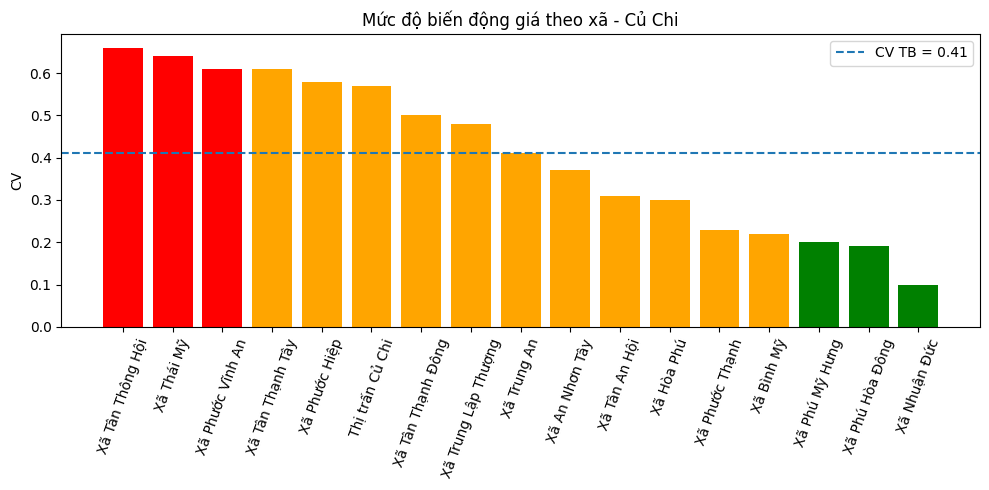

In [ ]:
cv_df = cc_stats.sort_values(by="CV", ascending=False)
cv_df = cv_df.dropna(subset=['CV'])
top3 = set(cv_df.head(3)['Phường'])
bottom3 = set(cv_df.tail(3)['Phường'])
colors = [
    'red' if w in top3
    else 'green' if w in bottom3
    else 'orange'
    for w in cv_df['Phường']
]
plt.figure(figsize=(10,5))
plt.bar(cv_df['Phường'], cv_df['CV'], color=colors)
cv_mean = cv_df['CV'].mean()
plt.axhline(
    y=cv_mean,
    linestyle='--',
    label=f'CV TB = {cv_mean:.2f}'
)
plt.xticks(rotation=70)
plt.ylabel("CV")
plt.title("Mức độ biến động giá theo xã - Củ Chi")
plt.legend()
plt.tight_layout()
plt.show()